In [1]:
import os
import numpy as np    # math
import pandas as pd    # data
import math
import matplotlib.pylab as plt
import seaborn as sns

# this trick is required to get plots to display inline with the rest of your notebook,
# not in a separate window
%matplotlib inline

# just some stylistic tweaks for seaborn
sns.set(style='ticks', palette='Set2')

The goal is to predict passenger survival.

In [3]:
path = "./data/titanic.csv"
# we will drop missing values this time
# But note: maybe things aren't missing at random, or missingness will be predictive. (Be careful of leakage in this case)

df = pd.read_csv(path)[["survived", "pclass", "sex", "age", "fare"]].dropna()
# transform "sex" column to a numeric variable
df["female"] = (df.sex == "female").astype(int)
df = df.drop("sex", axis="columns")
# drop outliers
df = df[df.fare < 400]

df.head(7)

,survived,pclass,age,fare,female
0,1.0,1.0,29.0000,211.3375,1
1,1.0,1.0,0.9167,151.5500,0
2,0.0,1.0,2.0000,151.5500,1
3,0.0,1.0,30.0000,151.5500,0
4,0.0,1.0,25.0000,151.5500,1
5,1.0,1.0,48.0000,26.5500,0
6,1.0,1.0,63.0000,77.9583,1


Let's take a look at how well some of the variables split the data according to our target.

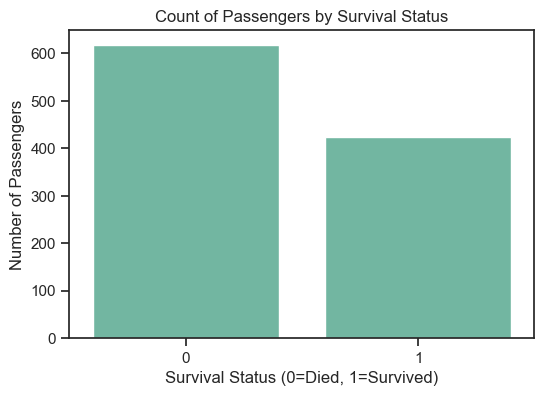

survived
0.0    0.59366
1.0    0.40634
Name: count, dtype: float64

In [5]:
# Base rate of survival
plt.figure(figsize=(6, 4))
sns.countplot(x='survived', data=df)
plt.title('Count of Passengers by Survival Status')
plt.xlabel('Survival Status (0=Died, 1=Survived)')
plt.ylabel('Number of Passengers')
plt.xticks([0, 1], ['0', '1']) # Explicitly set x-axis ticks to 0 and 1 with integer labels
plt.show()
plt.show()
df["survived"].value_counts() / df["survived"].count()

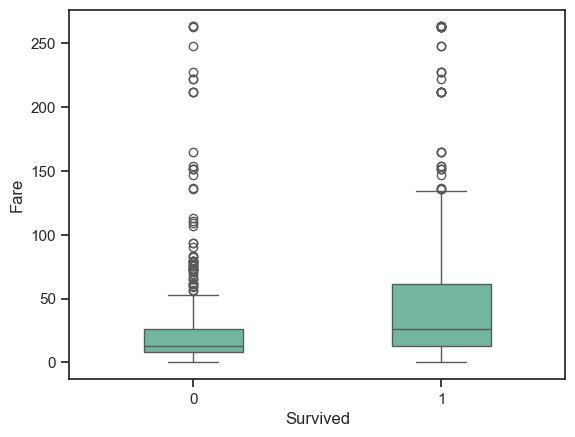

In [6]:
sns.boxplot(x = "survived", y = "fare", width = 0.4, data = df)
plt.xlabel("Survived")
plt.ylabel("Fare")
plt.xticks([0, 1], ["0", "1"])
plt.show()

Above we see boxplots that show the fare distribution grouped by our target variable (survival). The left boxplot corresponds to people that died and the right one to people that survived. Let's look at an alternative plot of the distribution of fare according to survival:

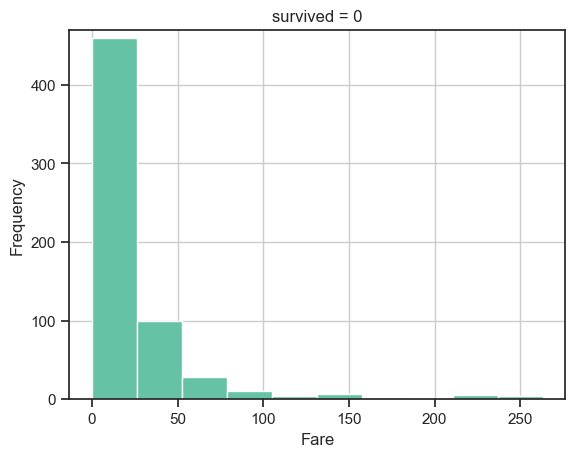

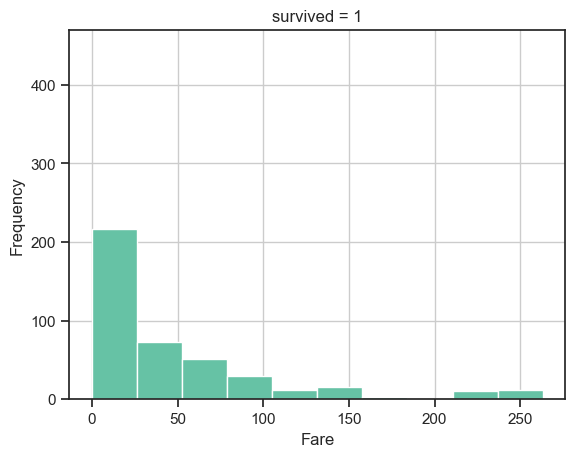

In [7]:
for r in range(2):
    hist = df[df.survived == r].hist("fare")
    plt.title("survived = " + str(r))
    plt.xlabel("Fare")
    plt.ylabel("Frequency")
    plt.ylim(0,470)
    plt.show()

We would use Fare to predict the survival. let's quantify the threshold = 50

In [8]:
# entropy funciton
def entropy(target_column):
    # get the counts of each target value
    target_counts = target_column.value_counts().astype(float).values
    total = target_column.count()
    # compute probas
    probas = target_counts / total
    # p_i * log_2 (p_i)
    entropy_components = probas * np.log2(probas)
    # return negative sum
    return - entropy_components.sum()

In [ ]:
# Information Gain
def information_gain(df, info_column, target_column, threshold):
    """ 
        computes H(target) - H(target | info > thresh) - H(target | info <= thresh)
    """
    #